# Sample project
This project aims to explore the relationship between mental health status and crime rates at the state level. Poor untreated mental health can often lead to violence, confusion, and impulsive behavior. Therefore, it is important to address the potential patterns and correlations that may exist. That way, we can implement policy programs, health insurance, mental health shelters, etc. to help solve crime from the ground-up rather than top-down. There are many confounders to crime rates as well, so CDC economic data including health insurance rates, unemployment rates, and poverty rates are analyzed as well. 

In [3]:
import os
from config import CDC_API_URL, FBI_XLSX_PATH, CENSUS_CSV_PATH, RESULTS_DIR, DATA_DIR
from load import get_mental_health_data, get_crime_data, get_census_data
from process import process_cdc_data, process_crime_data, process_census_data, merge_datasets
from analyze import plot_statistics

## Directory Setup

In [4]:
# Create a data directory
os.makedirs(DATA_DIR, exist_ok=True)


## Load Data

In [5]:
print("----- LOADING DATA ----- ")
cdc_raw = get_mental_health_data(CDC_API_URL)
fbi_raw = get_crime_data(FBI_XLSX_PATH)
census_raw = get_census_data(CENSUS_CSV_PATH)


----- LOADING DATA ----- 
--- Loading CDC Mental Health Data from API: https://data.cdc.gov/resource/5eh7-pjx8.json?$limit=50000 ---
Mental Health data loaded: 1086 rows
--- Loading Crime Data from ../data/Crime_Data.xlsx ---
FBI data loaded: 2446 rows
--- Loading Census Data from ../data/Census_Data.csv ---
Census data loaded: 52 rows


## Process Data

In [6]:
print("----- PROCESSING DATA ----- ")
cdc_df = process_cdc_data(cdc_raw)
fbi_df = process_crime_data(fbi_raw)
census_df = process_census_data(census_raw)
merged = merge_datasets(cdc_df, fbi_df, census_df)

----- PROCESSING DATA ----- 
--- Processing CDC Mental Health Data ---
CDC data processed: 54 rows
--- Processing Crime Data ---
Crime data processed: 46 rows
--- Processing Census Data ---
Census data processed: 52 rows
--- Merging Datasets ---
Merged dataset: 46 rows, 7 columns


## Analyze Data

### Individual Variable Distributions

----- ANALYZING DATA ----- 
--- Plotting statistics for CDC_Mental_Health ---


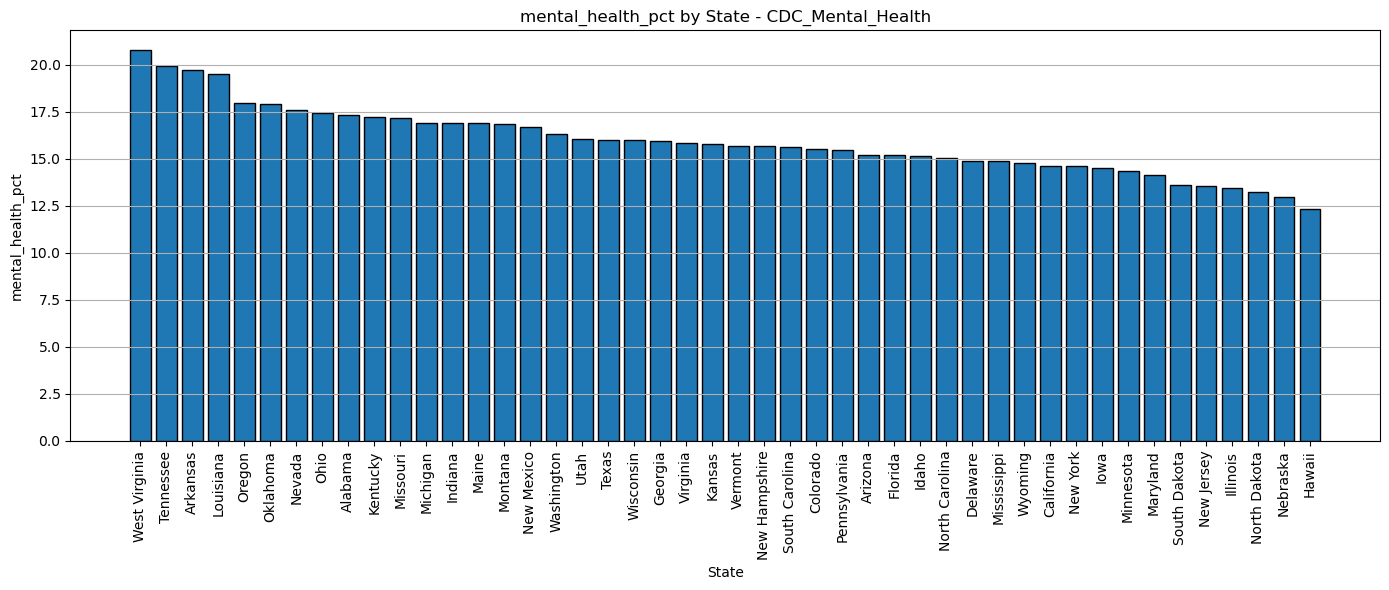

In [7]:
print("----- ANALYZING DATA ----- ")

# --- Individual distributions ---
plot_statistics(merged[['state_name', 'mental_health_pct']], 'CDC_Mental_Health', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for FBI_Crime ---


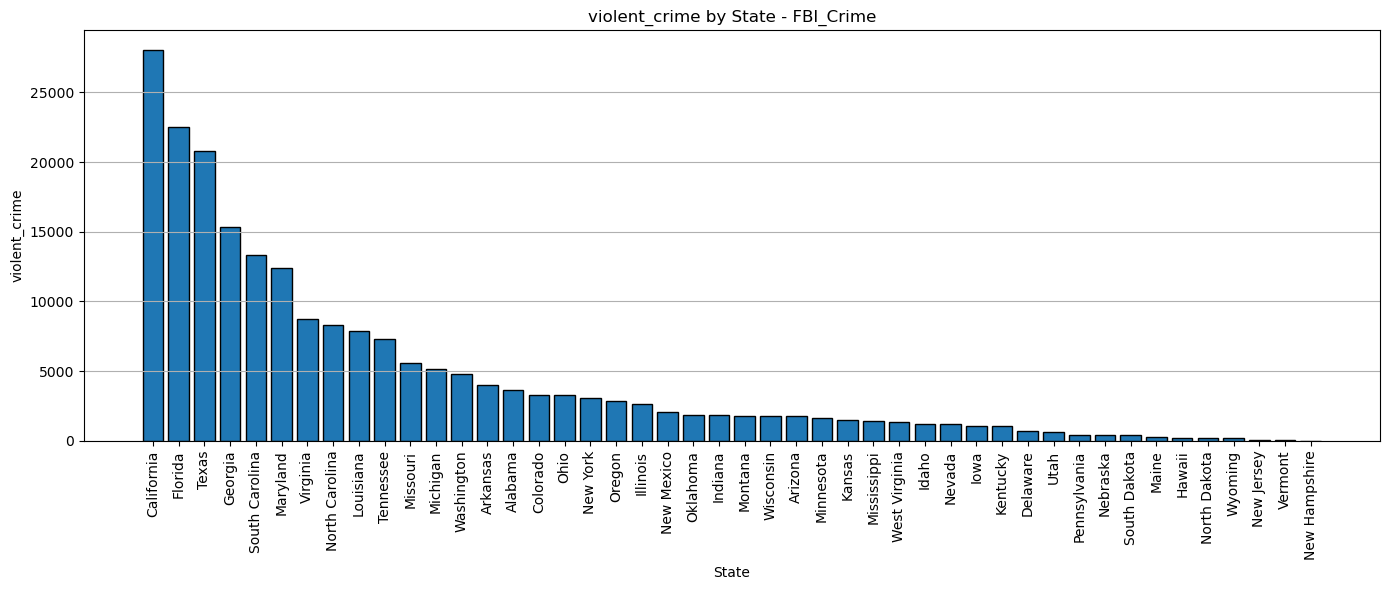

In [8]:
plot_statistics(merged[['state_name', 'violent_crime']], 'FBI_Crime', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for Census_Poverty ---


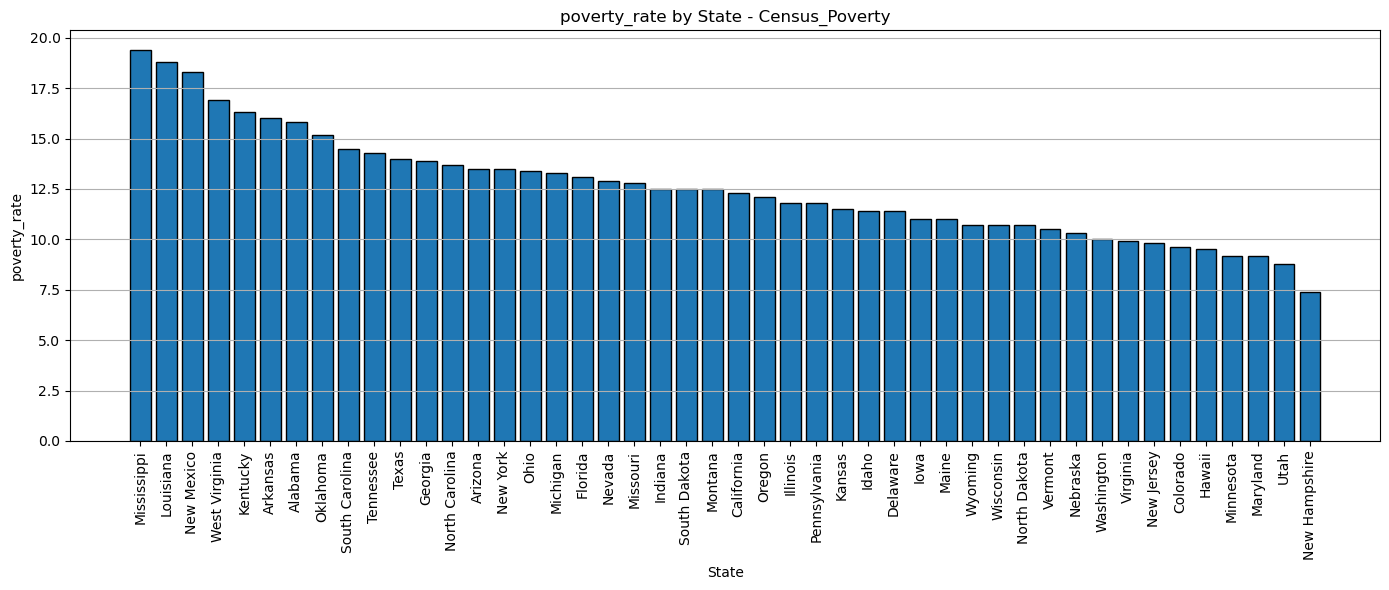

In [9]:
plot_statistics(merged[['state_name', 'poverty_rate']], 'Census_Poverty', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for Census_Insurance ---


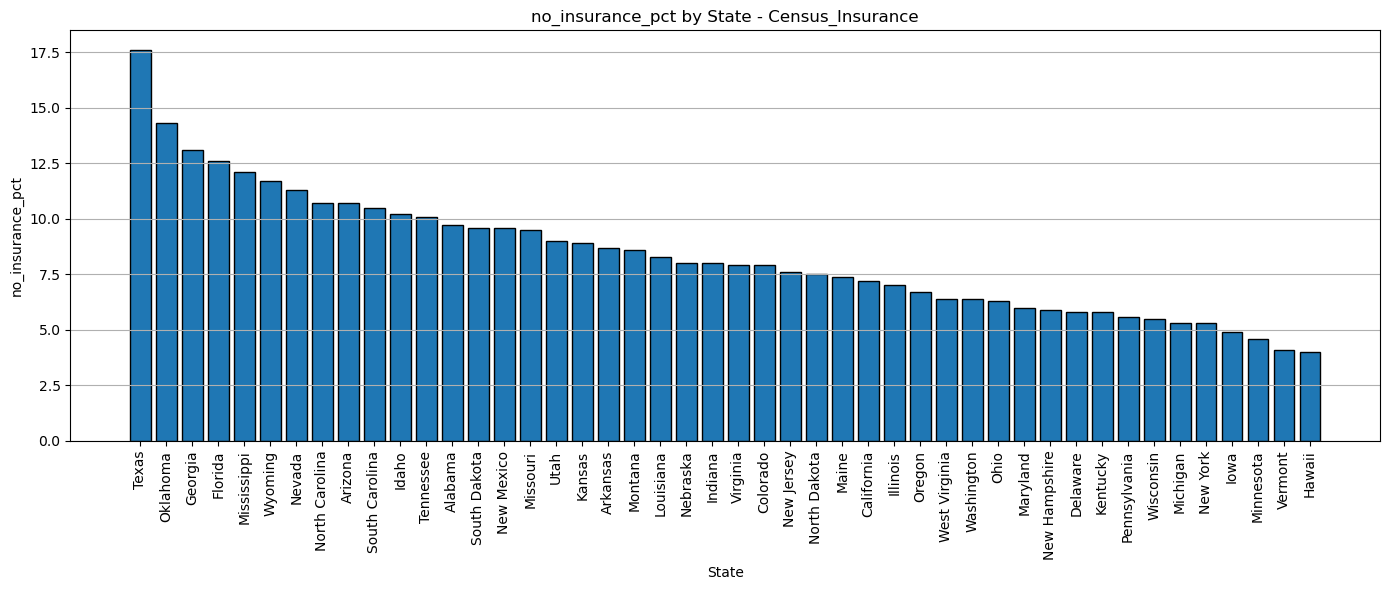

In [10]:
plot_statistics(merged[['state_name', 'no_insurance_pct']], 'Census_Insurance', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for Census_Unemployment ---


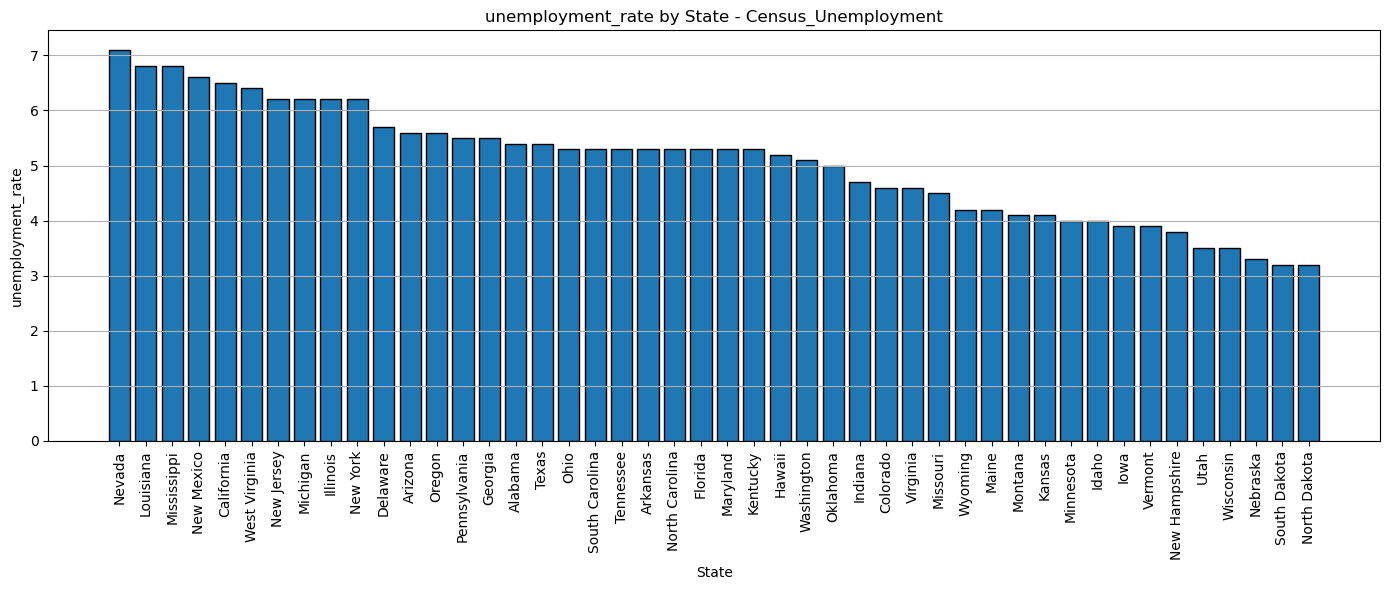

In [11]:
plot_statistics(merged[['state_name', 'unemployment_rate']], 'Census_Unemployment', result_dir=RESULTS_DIR, notebook_plot=True)

### Scatter Plots: Mental Health vs Other Variables

--- Plotting statistics for MentalHealth_vs_Crime ---


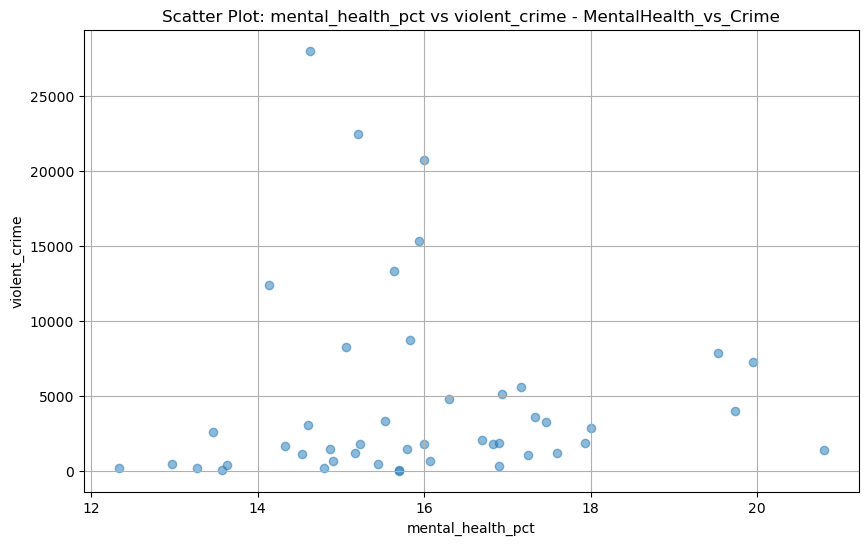

In [12]:
plot_statistics(merged[['mental_health_pct', 'violent_crime']], 'MentalHealth_vs_Crime', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for MentalHealth_vs_Poverty ---


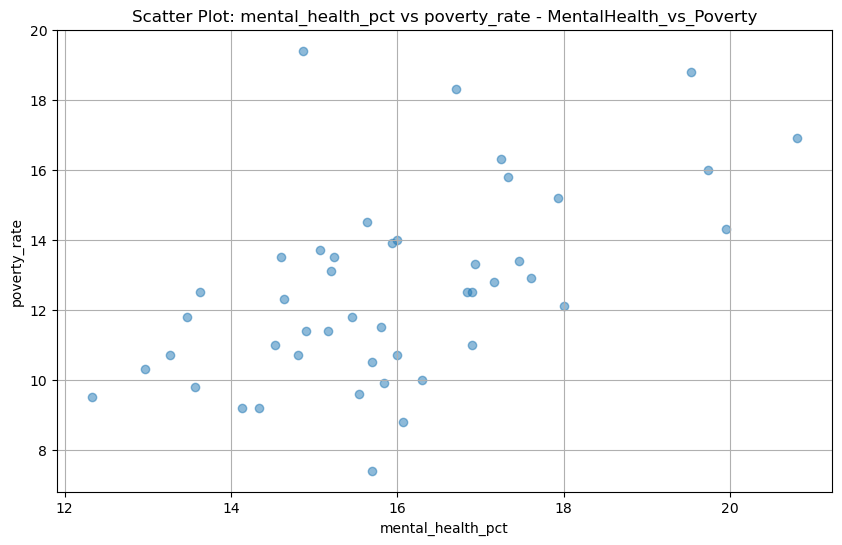

In [13]:
plot_statistics(merged[['mental_health_pct', 'poverty_rate']], 'MentalHealth_vs_Poverty', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for MentalHealth_vs_Unemployment ---


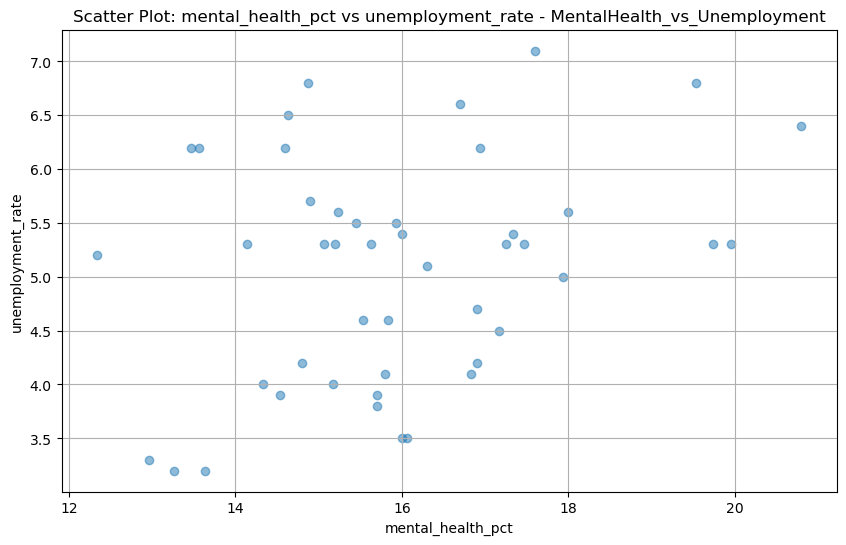

In [14]:
plot_statistics(merged[['mental_health_pct', 'unemployment_rate']], 'MentalHealth_vs_Unemployment', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for MentalHealth_vs_Insurance ---


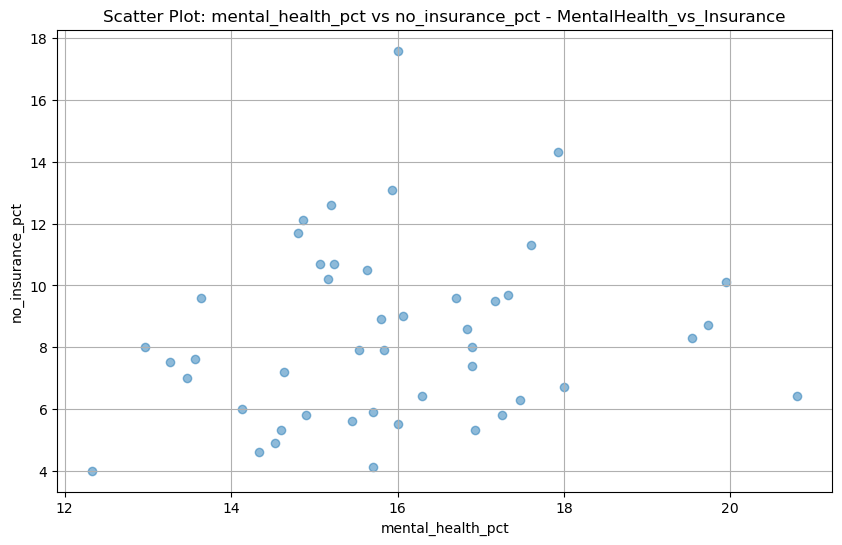

In [15]:
plot_statistics(merged[['mental_health_pct', 'no_insurance_pct']], 'MentalHealth_vs_Insurance', result_dir=RESULTS_DIR, notebook_plot=True)

### Scatter Plots: Crime vs Socioeconomic Variables

--- Plotting statistics for Crime_vs_Poverty ---


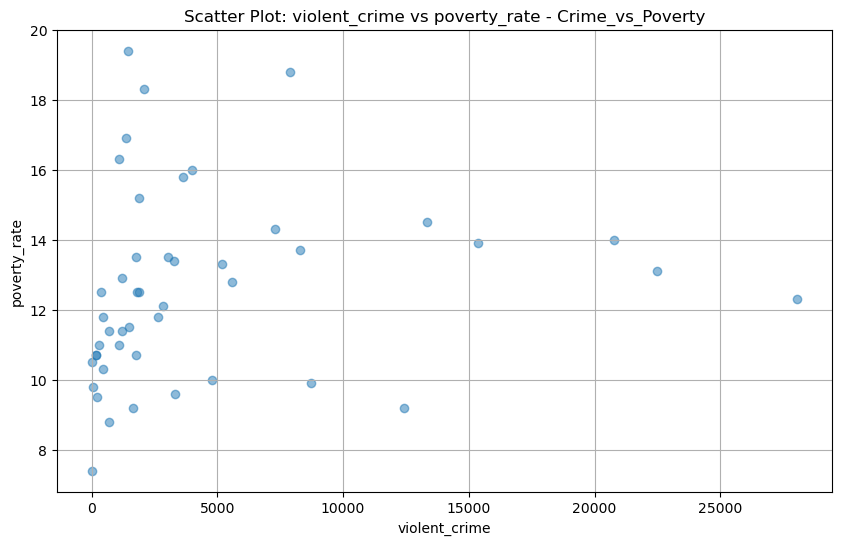

In [16]:
plot_statistics(merged[['violent_crime', 'poverty_rate']], 'Crime_vs_Poverty', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for Crime_vs_Unemployment ---


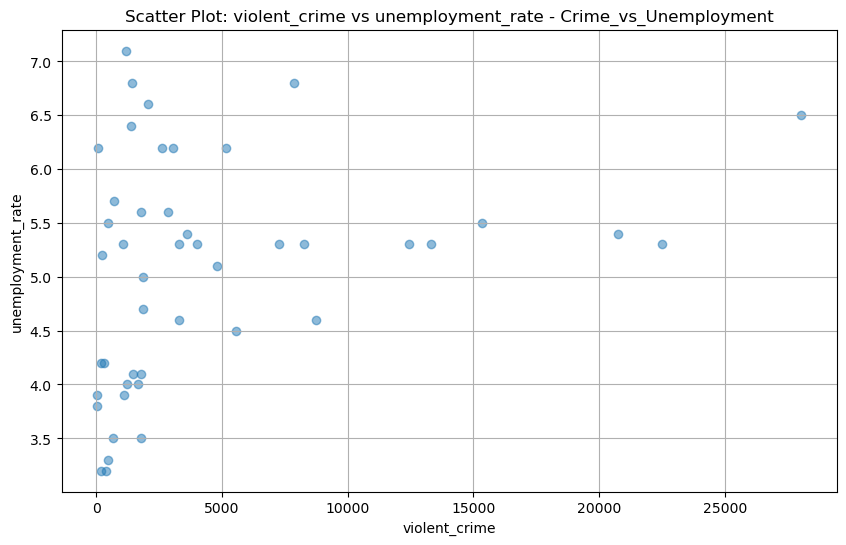

In [17]:
plot_statistics(merged[['violent_crime', 'unemployment_rate']], 'Crime_vs_Unemployment', result_dir=RESULTS_DIR, notebook_plot=True)

--- Plotting statistics for Crime_vs_Insurance ---

--- Data collection and plotting complete. Check the 'results' directory. ---


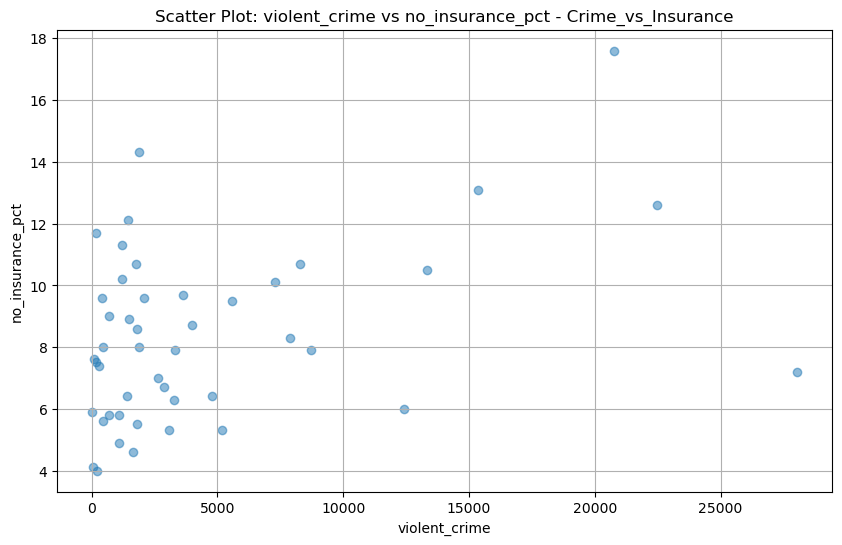

In [18]:
plot_statistics(merged[['violent_crime', 'no_insurance_pct']], 'Crime_vs_Insurance', result_dir=RESULTS_DIR, notebook_plot=True)

print("\n--- Data collection and plotting complete. Check the 'results' directory. ---")